### Goal:

Gain insights into similarity between countries and regions of the world by experimenting with different cluster amounts.

#### 1) Importing Necessary Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.base import BaseEstimator, TransformerMixin

#### 2) Loading Data:

In [2]:
df = pd.read_csv('CIA_Country_Facts.csv')

In [3]:
df.head()

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,0.22,87.65,1.0,46.60,20.34,0.380,0.240,0.380
1,Albania,EASTERN EUROPE,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,4.42,74.49,3.0,15.11,5.22,0.232,0.188,0.579
2,Algeria,NORTHERN AFRICA,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,0.25,96.53,1.0,17.14,4.61,0.101,0.600,0.298
3,American Samoa,OCEANIA,57794,199,290.4,58.29,-20.71,9.27,8000.0,97.0,259.5,10.00,15.00,75.00,2.0,22.46,3.27,NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,152.1,0.00,6.60,4.05,19000.0,100.0,497.2,2.22,0.00,97.78,3.0,8.71,6.25,NaN,NaN,NaN


In [4]:
df.shape

(227, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             227 non-null    object 
 1   Region                              227 non-null    object 
 2   Population                          227 non-null    int64  
 3   Area (sq. mi.)                      227 non-null    int64  
 4   Pop. Density (per sq. mi.)          227 non-null    float64
 5   Coastline (coast/area ratio)        227 non-null    float64
 6   Net migration                       224 non-null    float64
 7   Infant mortality (per 1000 births)  224 non-null    float64
 8   GDP ($ per capita)                  226 non-null    float64
 9   Literacy (%)                        209 non-null    float64
 10  Phones (per 1000)                   223 non-null    float64
 11  Arable (%)                          225 non-n

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Population,227.0,2.874028e+07,1.178913e+08,7026.000,437624.00000,4786994.000,1.749777e+07,1.313974e+09
Area (sq. mi.),227.0,5.982270e+05,1.790282e+06,2.000,4647.50000,86600.000,4.418110e+05,1.707520e+07
Pop. Density (per sq. mi.),227.0,3.790471e+02,1.660186e+03,0.000,29.15000,78.800,1.901500e+02,1.627150e+04
Coastline (coast/area ratio),227.0,2.116533e+01,7.228686e+01,0.000,0.10000,0.730,1.034500e+01,8.706600e+02
Net migration,224.0,3.812500e-02,4.889269e+00,-20.990,-0.92750,0.000,9.975000e-01,2.306000e+01
Infant mortality (per 1000 births),224.0,3.550696e+01,3.538990e+01,2.290,8.15000,21.000,5.570500e+01,1.911900e+02
GDP ($ per capita),226.0,9.689823e+03,1.004914e+04,500.000,1900.00000,5550.000,1.570000e+04,5.510000e+04
Literacy (%),209.0,8.283828e+01,1.972217e+01,17.600,70.60000,92.500,9.800000e+01,1.000000e+02
Phones (per 1000),223.0,2.360614e+02,2.279918e+02,0.200,37.80000,176.200,3.896500e+02,1.035600e+03
Arable (%),225.0,1.379711e+01,1.304040e+01,0.000,3.22000,10.420,2.000000e+01,6.211000e+01


- Most of the features are numerical with a couple of categorical features.
- There are some missing values in data.

In [7]:
df.isna().sum() / len(df) * 100

Country                               0.000000
Region                                0.000000
Population                            0.000000
Area (sq. mi.)                        0.000000
Pop. Density (per sq. mi.)            0.000000
Coastline (coast/area ratio)          0.000000
Net migration                         1.321586
Infant mortality (per 1000 births)    1.321586
GDP ($ per capita)                    0.440529
Literacy (%)                          7.929515
Phones (per 1000)                     1.762115
Arable (%)                            0.881057
Crops (%)                             0.881057
Other (%)                             0.881057
Climate                               9.691630
Birthrate                             1.321586
Deathrate                             1.762115
Agriculture                           6.607930
Industry                              7.048458
Service                               6.607930
dtype: float64

- We will Impute Missing Values in features that has higher missingg values.
- For features having smaller missing value percentage (Net migration, Infant mortality (per 1000 births), GDP ($ per capita), Phones (per 1000), Arable (%), Crops (%), Other (%), Birthrate, Deathrate), they can be dropped.

#### 3) Data Exploration and Transforamtion:

##### 1) Exploration:

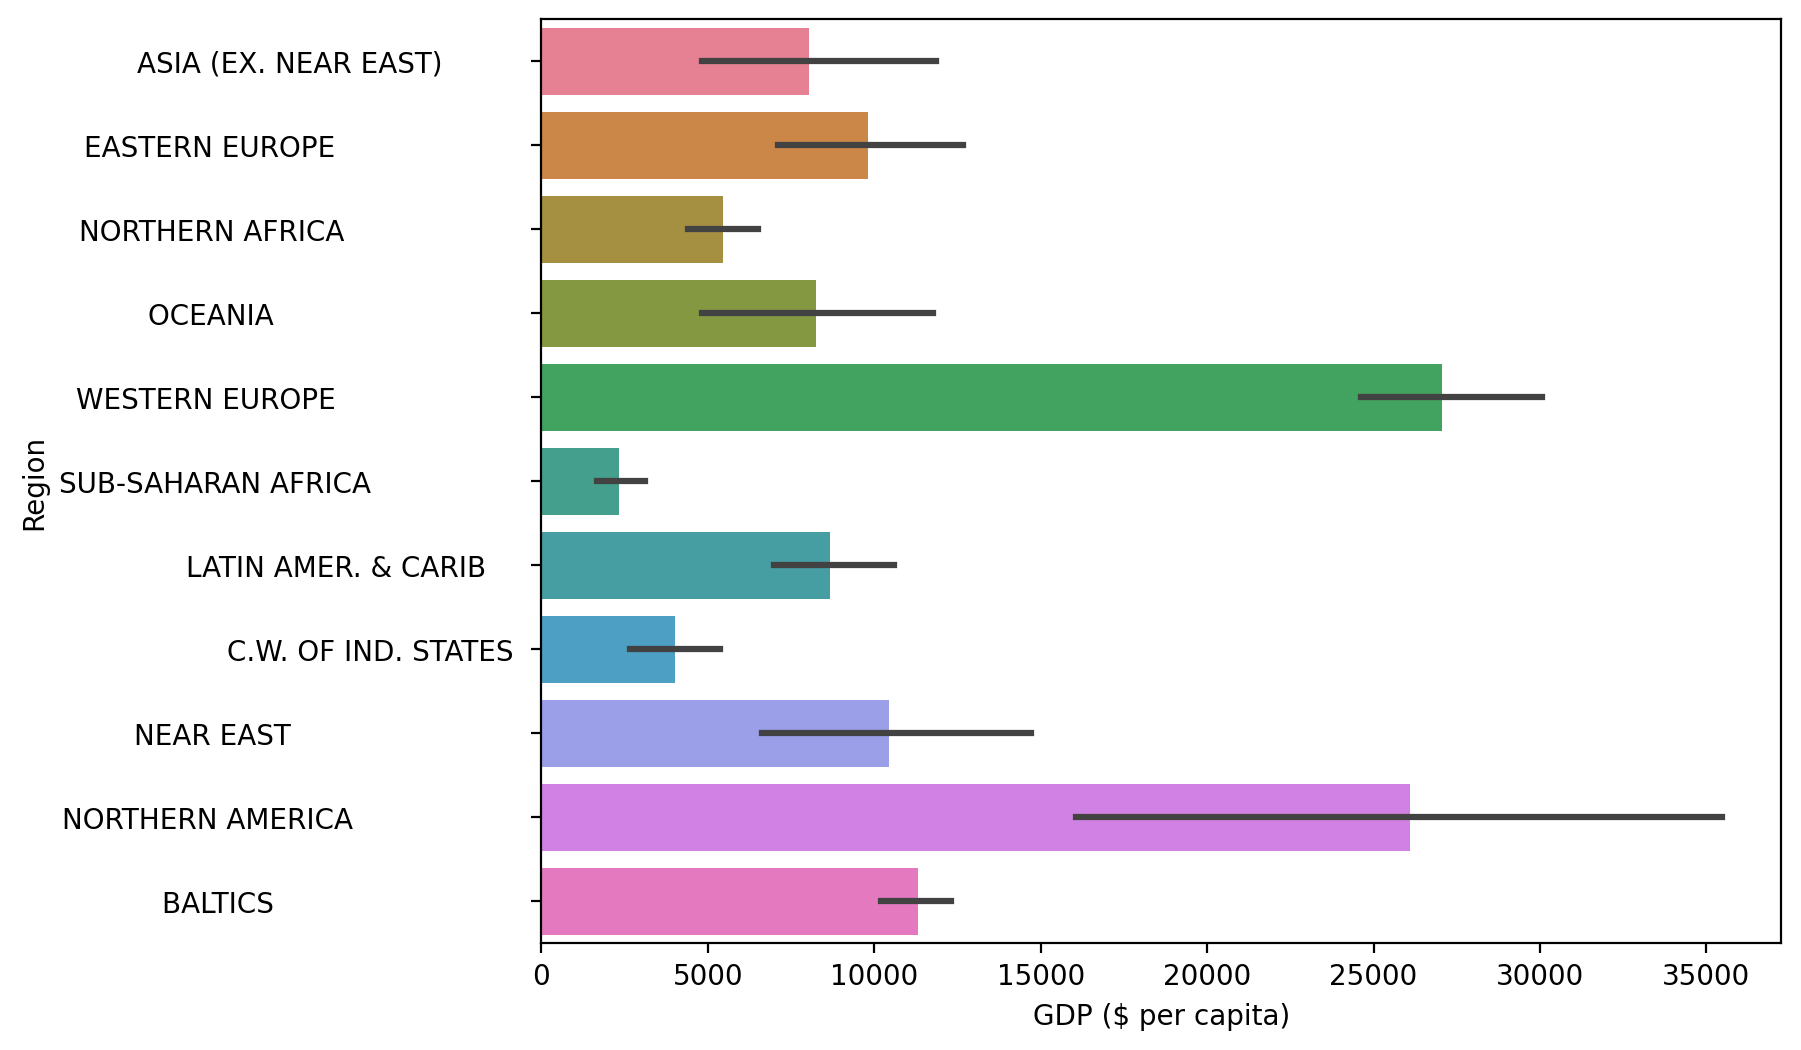

In [8]:
# Region Wise GDP:

plt.figure(figsize= (8,6), dpi= 200)
sns.barplot(data= df, x= "GDP ($ per capita)", y= "Region", hue= 'Region')
plt.show()

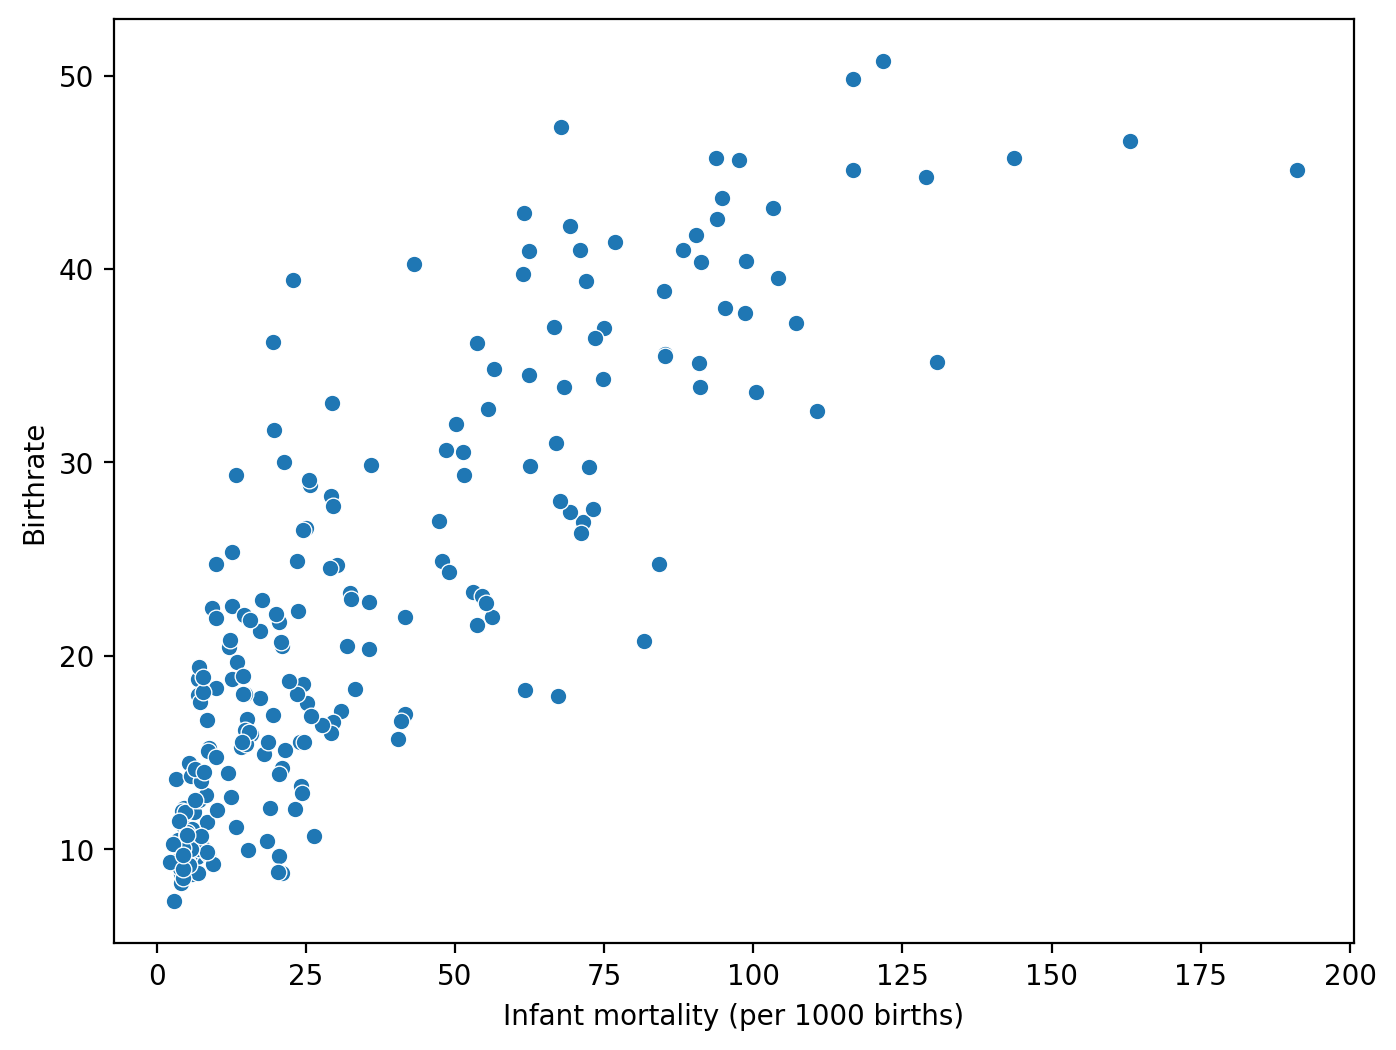

In [9]:
# Infant Mortality Rate vs. Birth Rate:

plt.figure(figsize= (8,6), dpi= 200)
sns.scatterplot(data= df, x= "Infant mortality (per 1000 births)", y= "Birthrate")
plt.show()

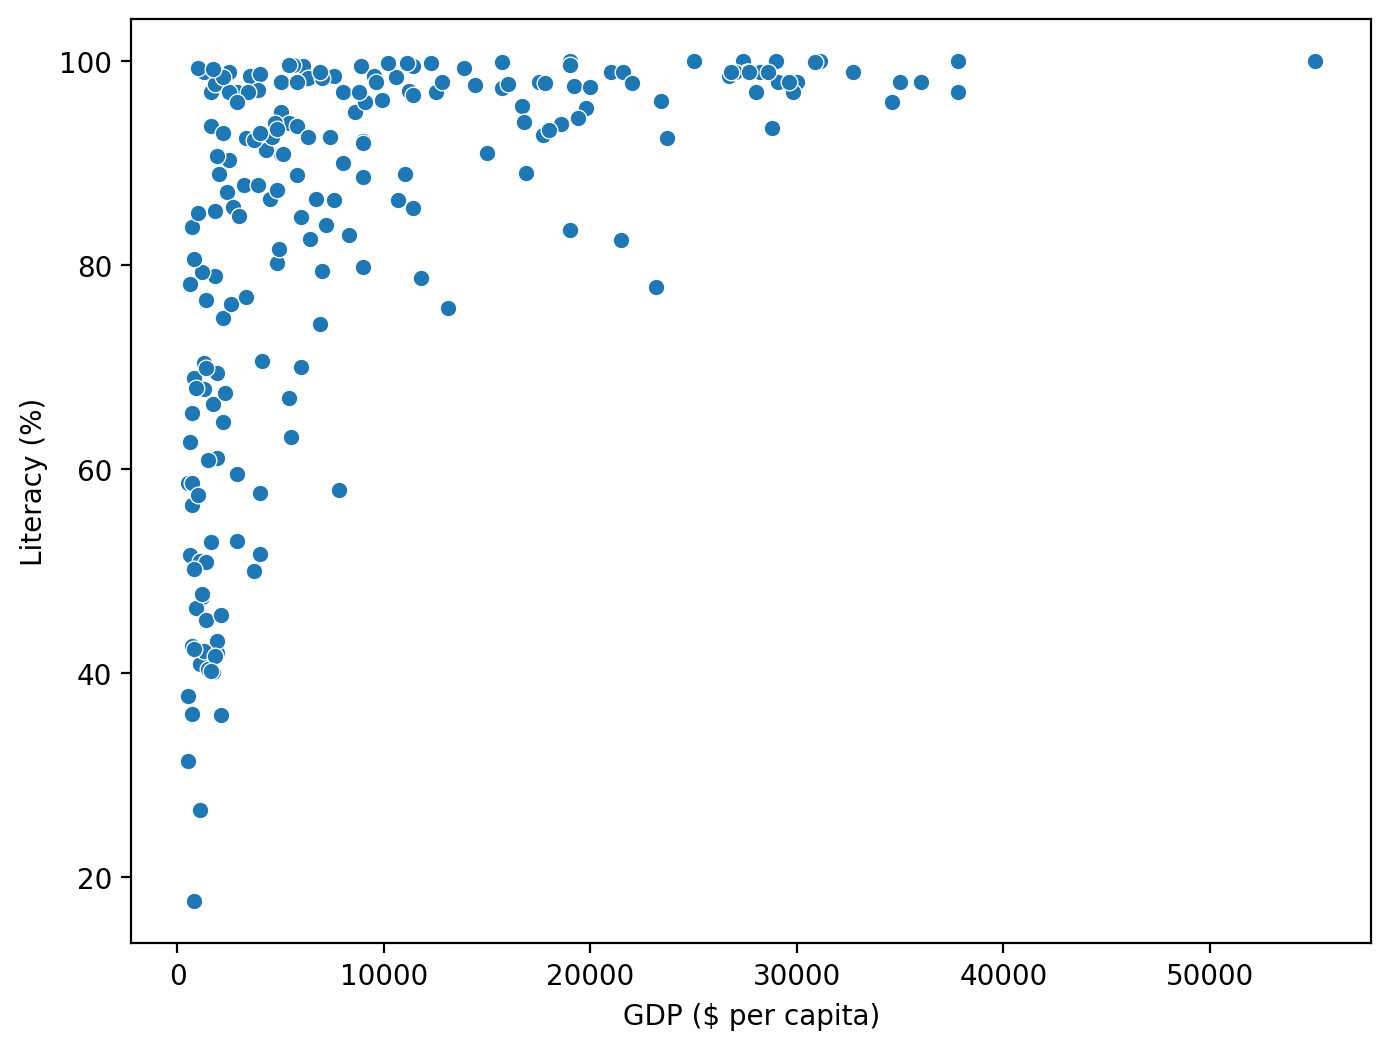

In [10]:
# GDP Vs. Literacy:

plt.figure(figsize= (8,6), dpi= 200)
sns.scatterplot(data= df, x= "GDP ($ per capita)", y= "Literacy (%)")
plt.show()

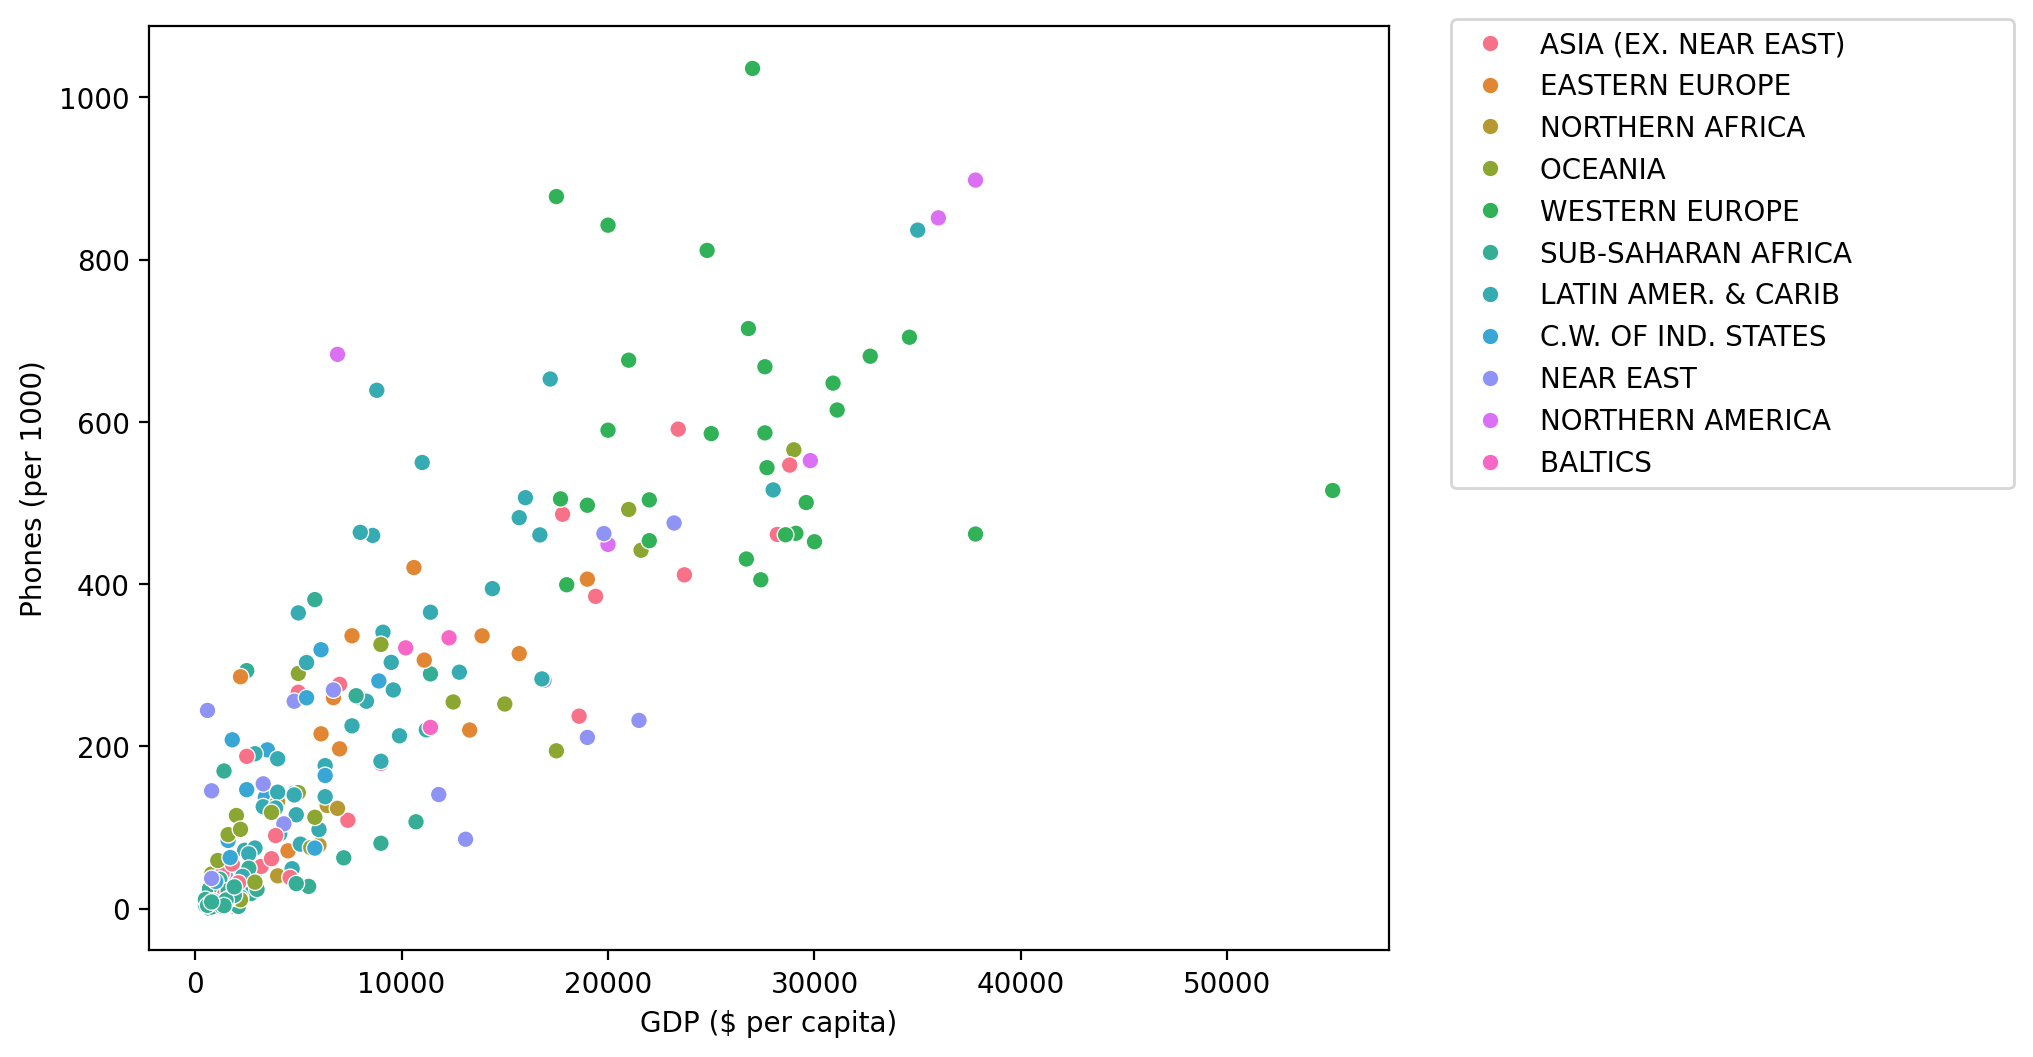

In [11]:
# GDP vs. Phones per 1000 People:

plt.figure(figsize=(8,6),dpi=200)
sns.scatterplot(data=df,x='GDP ($ per capita)',y='Phones (per 1000)',hue='Region')
plt.legend(loc=(1.05,0.5))
plt.show()

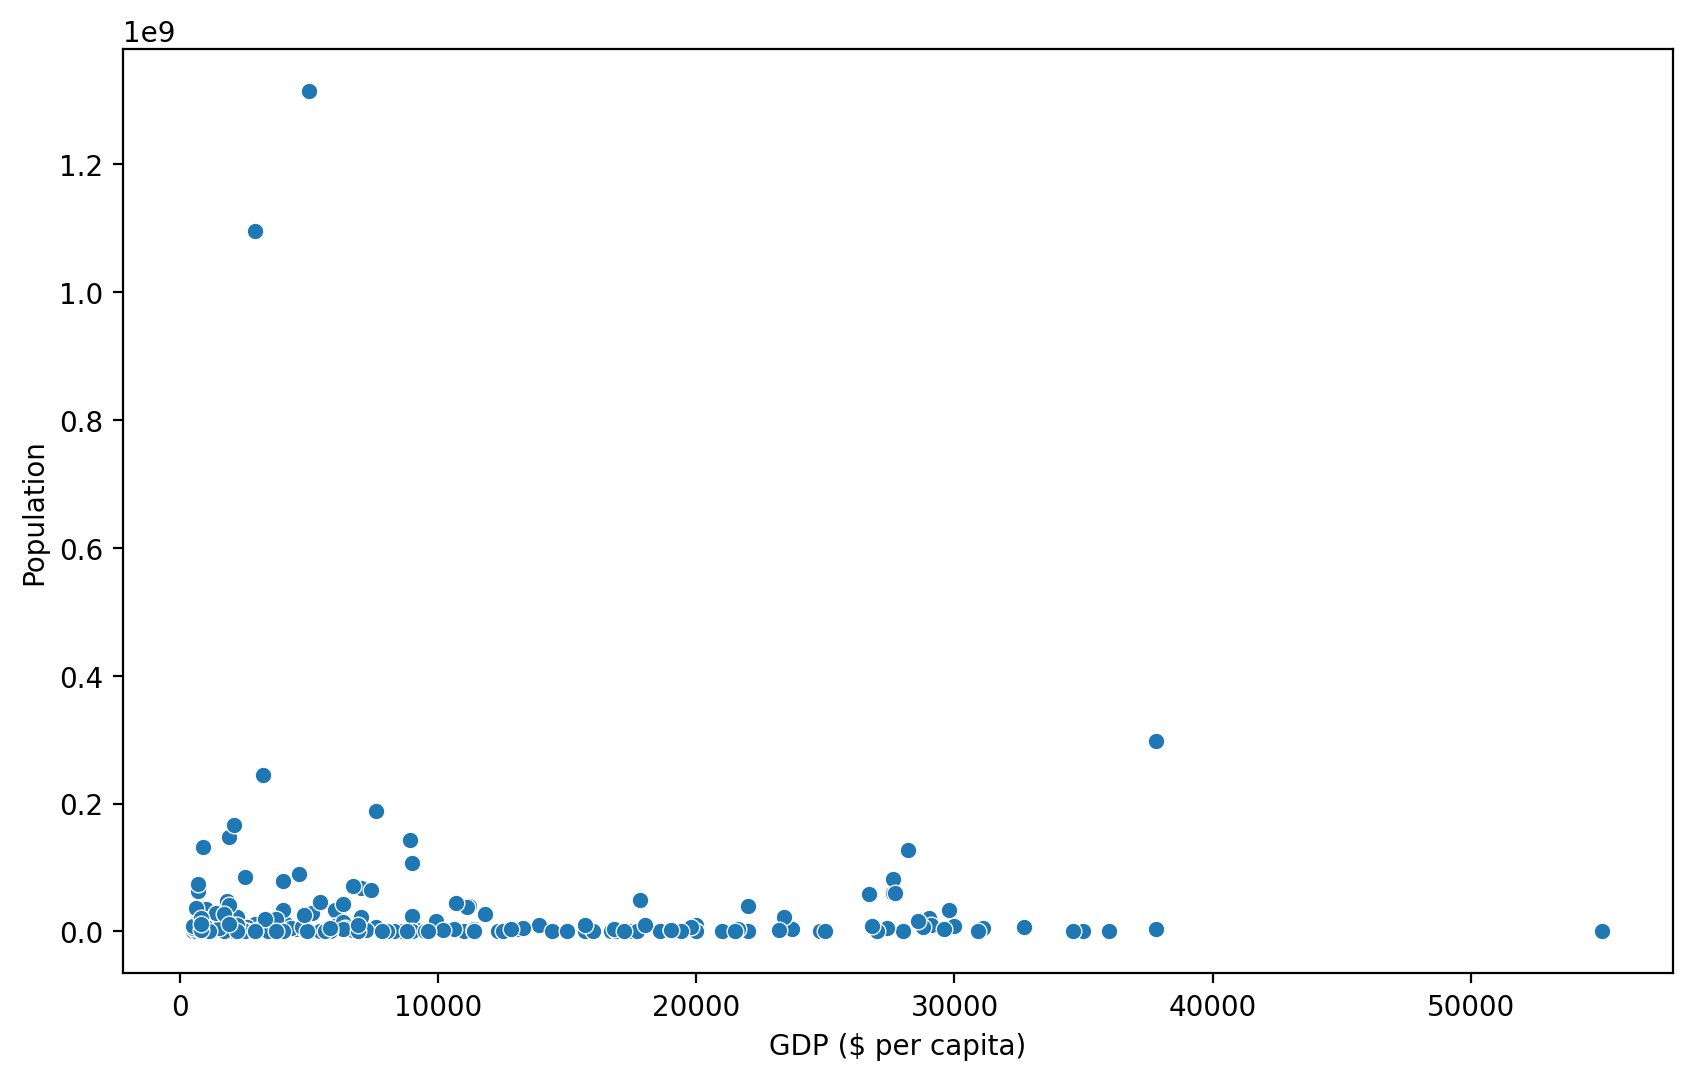

In [12]:
# Population Vs. GDP:

plt.figure(figsize=(10,6),dpi=200)
sns.scatterplot(data=df,x='GDP ($ per capita)',y='Population')
plt.show()

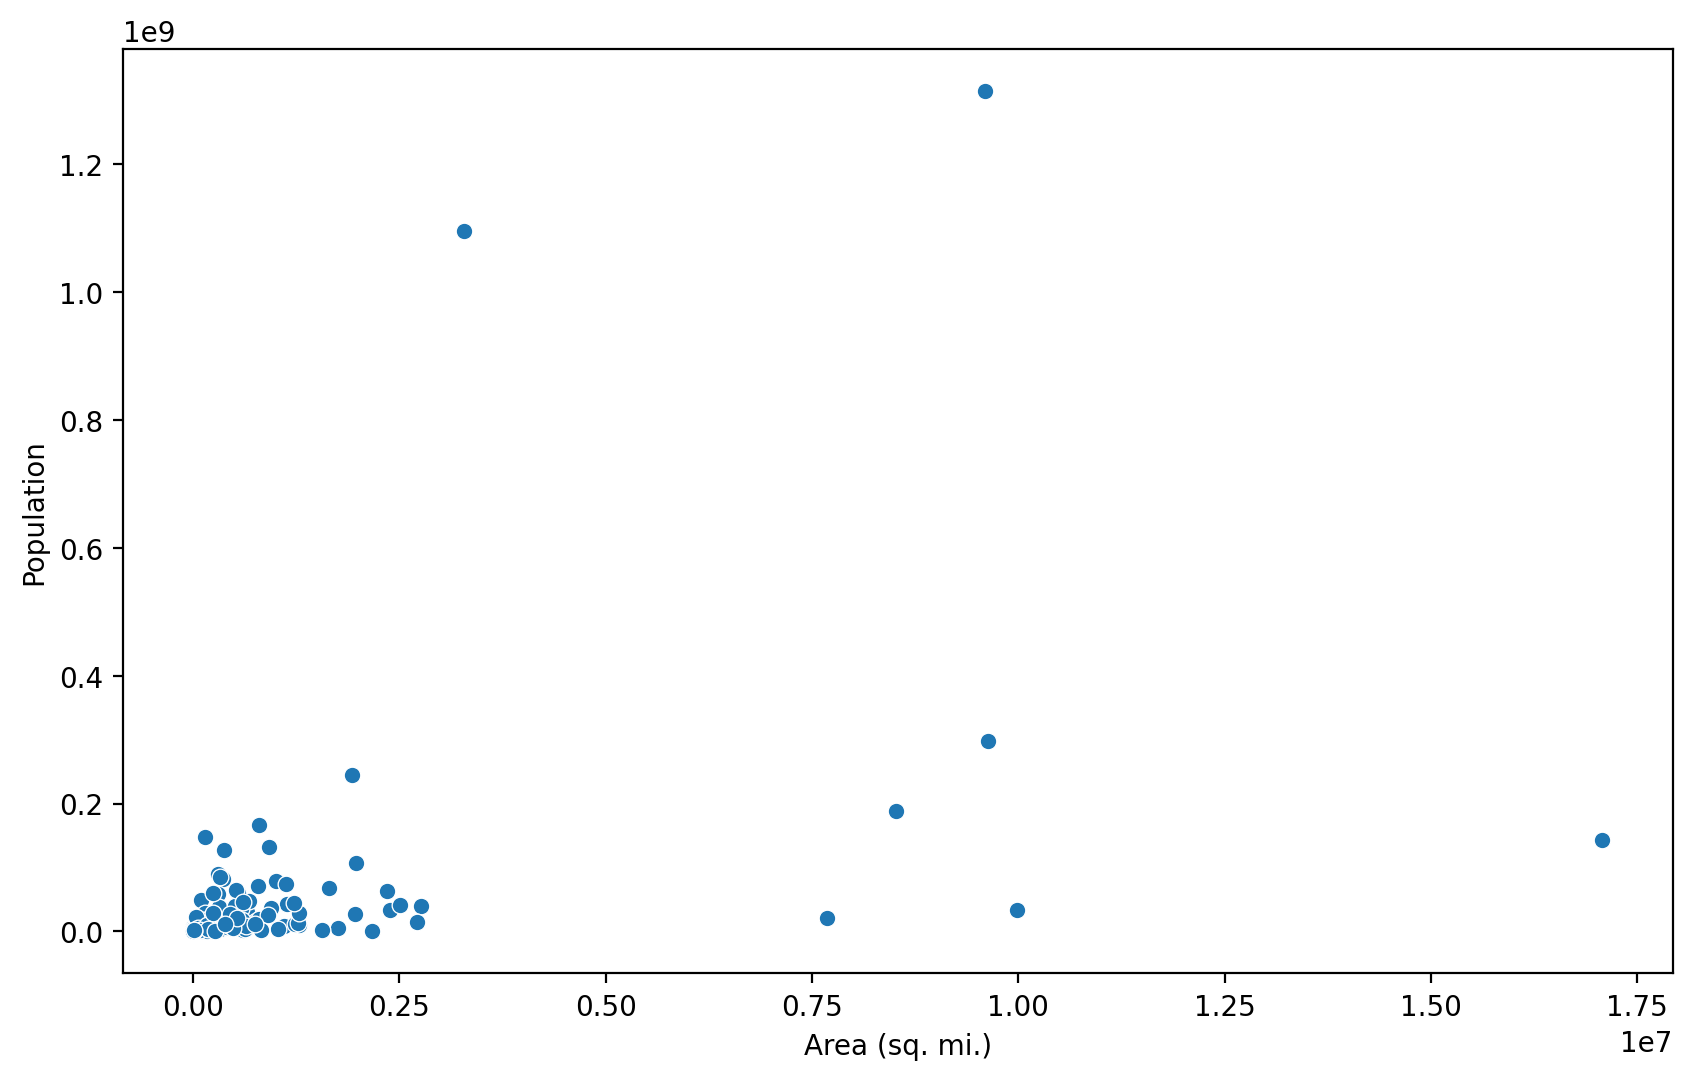

In [13]:
# Area vs. Population:

plt.figure(figsize=(10,6),dpi=200)
sns.scatterplot(data=df,x='Area (sq. mi.)',y='Population')
plt.show()

##### 2) Missing Values Imputation:

In [14]:
df.isna().sum() / len(df) * 100

Country                               0.000000
Region                                0.000000
Population                            0.000000
Area (sq. mi.)                        0.000000
Pop. Density (per sq. mi.)            0.000000
Coastline (coast/area ratio)          0.000000
Net migration                         1.321586
Infant mortality (per 1000 births)    1.321586
GDP ($ per capita)                    0.440529
Literacy (%)                          7.929515
Phones (per 1000)                     1.762115
Arable (%)                            0.881057
Crops (%)                             0.881057
Other (%)                             0.881057
Climate                               9.691630
Birthrate                             1.321586
Deathrate                             1.762115
Agriculture                           6.607930
Industry                              7.048458
Service                               6.607930
dtype: float64

- For simplicity, we will impute higher missing values feature with a custom imputation, which will fill in missing values with mean of the Region the record belongs to.

In [15]:
class Imputation(BaseEstimator, TransformerMixin):
    '''
    Fills in missing values for a given feature using Mean based on the Region the given record belongs to.
    If fails to do so, fill in missing values with global mean of target column.
    '''

    def __init__(self, group_col = 'Region', target_col= None):
        self.group_col = group_col
        self.target_col = target_col

    def fit(self, X, y= None):
        if self.target_col is None:
            raise ValueError('Target Column Name must be Provided.')

        # Calculate the mean of the target column grouped by the group column:
        # a Series where index is Region and value is the Mean:
        self.imputation_map_ = X.groupby(self.group_col)[self.target_col].mean()

        # Global Mean for fallback incase above one fails:
        self.global_mean_ = X[self.target_col].mean()

        return self

    def transform(self, X):

        X= X.copy()

        # Checking if transformer is already fitted or not:
        if not hasattr(self, 'imputation_map_'):
            raise RuntimeError("You must fit the transformer before transforming")

        # Map the group column values to the learned means
        means = X[self.group_col].map(self.imputation_map_)

        # Fill NaNs in target with the mapped means
        X[self.target_col] = X[self.target_col].fillna(means)

        # Fill any remaining NaNs (unseen groups) with global mean
        X[self.target_col] = X[self.target_col].fillna(self.global_mean_)

        return X[[self.target_col]]

We wil use this Transformer to fill in Missing Values for all the Features having them.

##### 3) Feature wise transformations:

###### 1) Country:

In [16]:
df['Country'].nunique()

227

- Country name is not needed for Clustering, we can drop it.

In [17]:
df.drop('Country', axis= 1, inplace= True)

In [18]:
df.shape

(227, 19)

###### 2) Region:

In [19]:
df['Region']

0            ASIA (EX. NEAR EAST)         
1      EASTERN EUROPE                     
2      NORTHERN AFRICA                    
3      OCEANIA                            
4      WESTERN EUROPE                     
                      ...                 
222    NEAR EAST                          
223    NORTHERN AFRICA                    
224    NEAR EAST                          
225    SUB-SAHARAN AFRICA                 
226    SUB-SAHARAN AFRICA                 
Name: Region, Length: 227, dtype: object

In [20]:
# Removing extra spaces from 'ASIA (EX. NEAR EAST)':

df['Region'].str.strip() 

0      ASIA (EX. NEAR EAST)
1            EASTERN EUROPE
2           NORTHERN AFRICA
3                   OCEANIA
4            WESTERN EUROPE
               ...         
222               NEAR EAST
223         NORTHERN AFRICA
224               NEAR EAST
225      SUB-SAHARAN AFRICA
226      SUB-SAHARAN AFRICA
Name: Region, Length: 227, dtype: object

In [21]:
df['Region'] = df['Region'].value_counts()

- Nominal Categorical Feature.
- Transformagtion: One Hot Encoding.

In [22]:
region_pipe = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

###### 3) Population:

In [23]:
df['Population']

0      31056997
1       3581655
2      32930091
3         57794
4         71201
         ...   
222     2460492
223      273008
224    21456188
225    11502010
226    12236805
Name: Population, Length: 227, dtype: int64

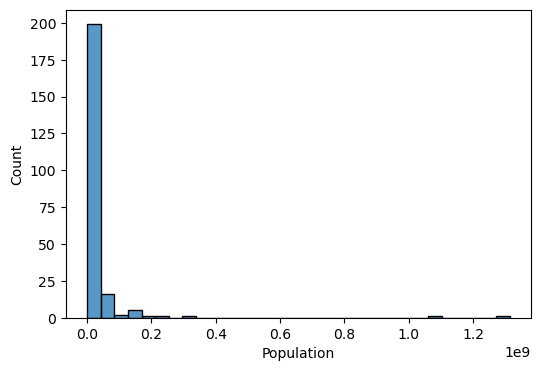

In [24]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Population')
plt.show()

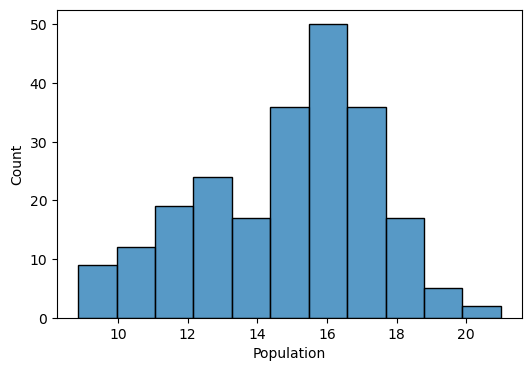

In [25]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['Population'].apply(np.log1p))
plt.show()

- Numerical Continuous feature with a extreme right skewed distribution
- Transformations: Log Transform, Scaling.

In [26]:
population_pipe = Pipeline([
    ('transformation', FunctionTransformer(np.log1p)),
    ('scaling', StandardScaler())
])

###### 4) Area (sq. mi.):

In [27]:
df['Area (sq. mi.)']

0       647500
1        28748
2      2381740
3          199
4          468
        ...   
222       5860
223     266000
224     527970
225     752614
226     390580
Name: Area (sq. mi.), Length: 227, dtype: int64

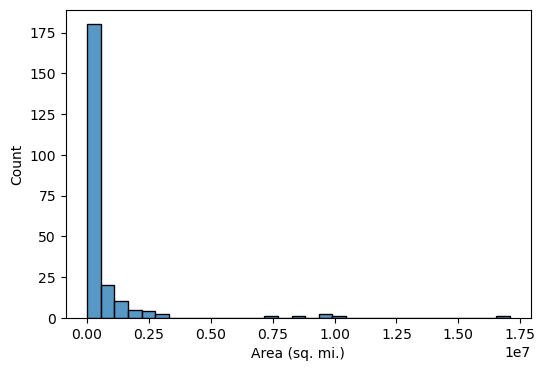

In [28]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Area (sq. mi.)')
plt.show()

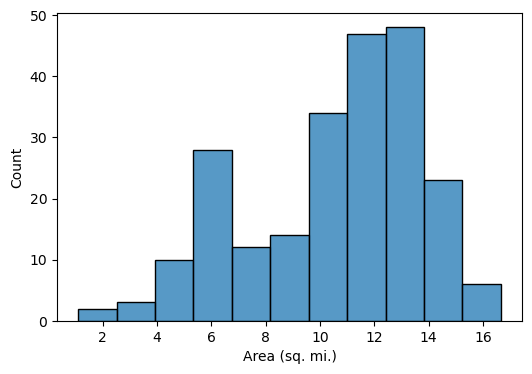

In [29]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['Area (sq. mi.)'].apply(np.log1p))
plt.show()

- Numerical Continuous feature with a extreme right skewed distribution
- Transformations: Log Transform, Scaling.

In [30]:
area_pipe = Pipeline([
    ('transformation', FunctionTransformer(np.log1p)),
    ('scaling', StandardScaler())
])

###### 5) Pop. Density (per sq. mi.):

In [31]:
df['Pop. Density (per sq. mi.)']

0       48.0
1      124.6
2       13.8
3      290.4
4      152.1
       ...  
222    419.9
223      1.0
224     40.6
225     15.3
226     31.3
Name: Pop. Density (per sq. mi.), Length: 227, dtype: float64

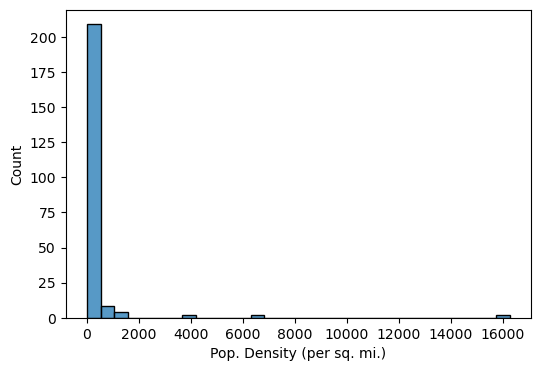

In [32]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Pop. Density (per sq. mi.)')
plt.show()

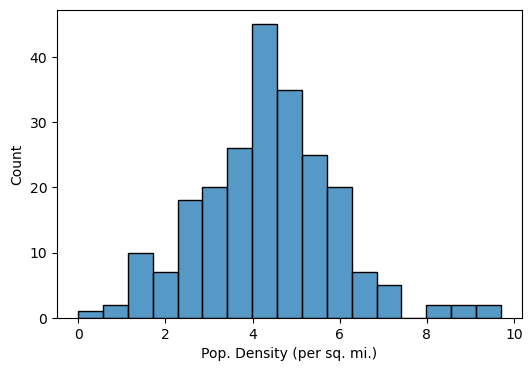

In [33]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['Pop. Density (per sq. mi.)'].apply(np.log1p))
plt.show()

- Numerical Continuous feature with a extreme right skewed distribution
- Transformations: Log Transform, Scaling.

In [34]:
popdensity_pipe = Pipeline([
    ('transformation', FunctionTransformer(np.log1p)),
    ('scaling', StandardScaler())
])

###### 6) Coastline (coast/area ratio):

In [35]:
df['Coastline (coast/area ratio)']

0       0.00
1       1.26
2       0.04
3      58.29
4       0.00
       ...  
222     0.00
223     0.42
224     0.36
225     0.00
226     0.00
Name: Coastline (coast/area ratio), Length: 227, dtype: float64

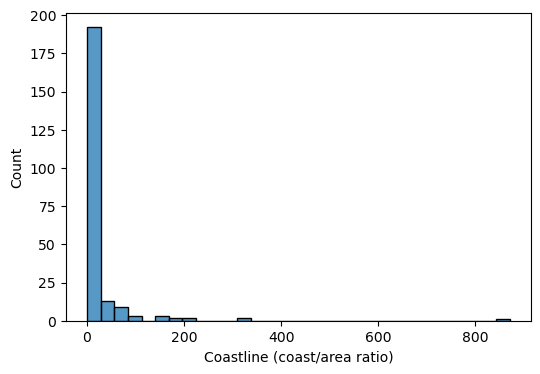

In [36]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Coastline (coast/area ratio)')
plt.show()

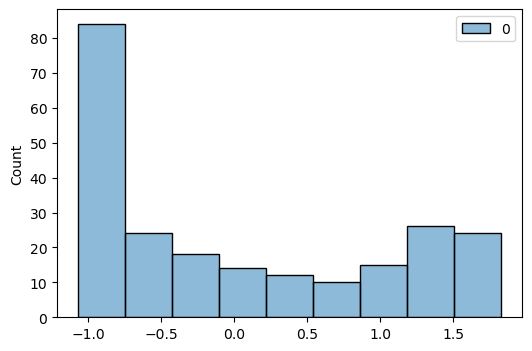

In [37]:
pt= PowerTransformer(method= 'yeo-johnson')
plt.figure(figsize= (6,4))
sns.histplot(data= pt.fit_transform(X= df[['Coastline (coast/area ratio)']]))
plt.show()

- Numerical Continuous feature with a extreme right skewed distribution
- Transformations: Log Transform, Scaling.

In [38]:
coastline_pipe = Pipeline([
    ('transformation', PowerTransformer(method= 'yeo-johnson')),
    ('scaling', StandardScaler())
])

###### 7) Net migration:

In [39]:
df['Net migration']

0      23.06
1      -4.93
2      -0.39
3     -20.71
4       6.60
       ...  
222     2.98
223      NaN
224     0.00
225     0.00
226     0.00
Name: Net migration, Length: 227, dtype: float64

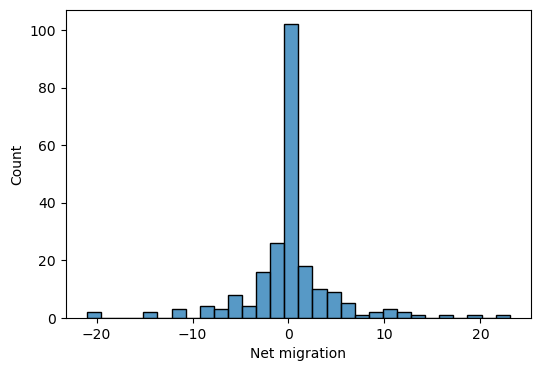

In [40]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Net migration')
plt.show()

- Numerical Continuous feature haveing close to Normal Distribution.
- Transformation: Scaling.

In [41]:
netmig_pipe = Pipeline([
    ('imputer', Imputation(group_col= 'Region', target_col= 'Net migration')),
    ('scaler', StandardScaler())
])

###### 8) Infant mortality (per 1000 births):

In [42]:
df['Infant mortality (per 1000 births)']

0      163.07
1       21.52
2       31.00
3        9.27
4        4.05
        ...  
222     19.62
223       NaN
224     61.50
225     88.29
226     67.69
Name: Infant mortality (per 1000 births), Length: 227, dtype: float64

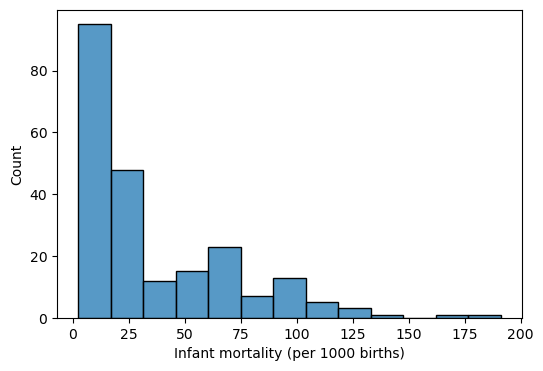

In [43]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Infant mortality (per 1000 births)')
plt.show()

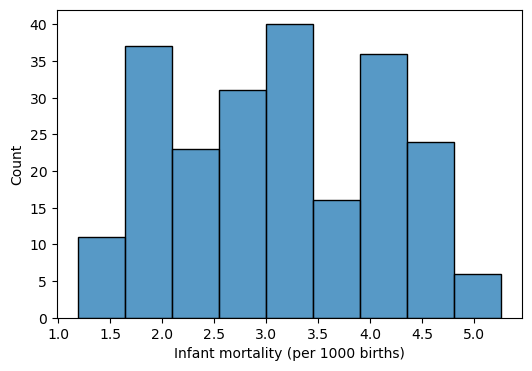

In [44]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['Infant mortality (per 1000 births)'].apply(np.log1p))
plt.show()

- Numerical Continuous feature with a extreme right skewed distribution
- Transformations: Log Transform, Scaling.

In [45]:
infantMRate_pipe = Pipeline([
    ('imputer', Imputation(group_col= 'Region', target_col= 'Infant mortality (per 1000 births)')),
    ('transformation', FunctionTransformer(np.log1p)),
    ('scaling', StandardScaler())
])

###### 9) GDP ($ per capita):

In [46]:
df['GDP ($ per capita)']

0        700.0
1       4500.0
2       6000.0
3       8000.0
4      19000.0
        ...   
222      800.0
223        NaN
224      800.0
225      800.0
226     1900.0
Name: GDP ($ per capita), Length: 227, dtype: float64

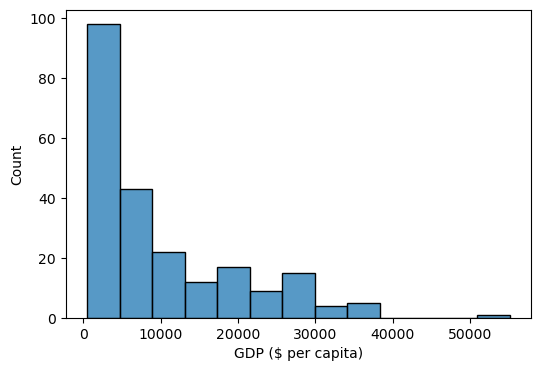

In [47]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'GDP ($ per capita)')
plt.show()

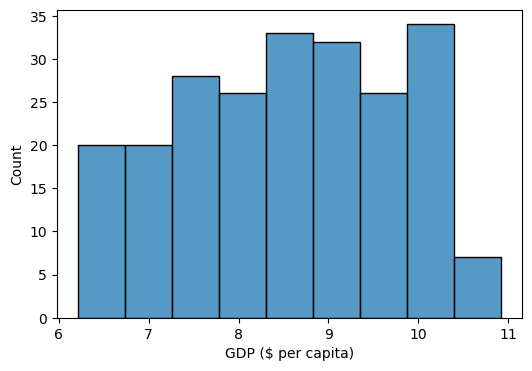

In [48]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['GDP ($ per capita)'].apply(np.log1p))
plt.show()

- Numerical Continuous feature with a extreme right skewed distribution
- Transformations: Log Transform, Scaling.

In [49]:
GDP_pipe = Pipeline([
    ('imputer', Imputation(group_col= 'Region', target_col= 'GDP ($ per capita)')),
    ('transformation', FunctionTransformer(np.log1p)),
    ('scaling', StandardScaler())
])

###### 10) Literacy (%):

In [50]:
df['Literacy (%)']

0       36.0
1       86.5
2       70.0
3       97.0
4      100.0
       ...  
222      NaN
223      NaN
224     50.2
225     80.6
226     90.7
Name: Literacy (%), Length: 227, dtype: float64

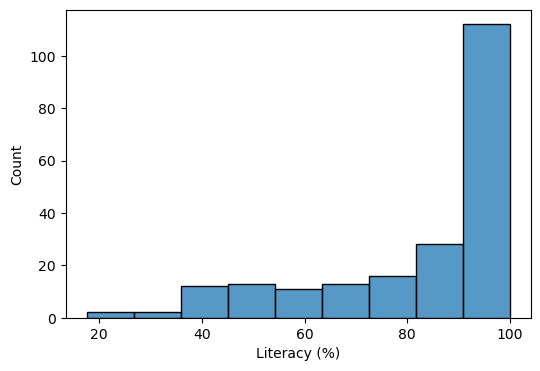

In [51]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Literacy (%)')
plt.show()

- Numerical Continuous feature with a left skewed distribution.
- Transformations: Scaling (Log transformations don't work).

In [52]:
literacy_pipe = Pipeline([
    ('imputer', Imputation(group_col= 'Region', target_col= 'Literacy (%)')),
    ('scaler', StandardScaler())
])

###### 11) Phones (per 1000):

In [53]:
df['Phones (per 1000)']

0        3.2
1       71.2
2       78.1
3      259.5
4      497.2
       ...  
222    145.2
223      NaN
224     37.2
225      8.2
226     26.8
Name: Phones (per 1000), Length: 227, dtype: float64

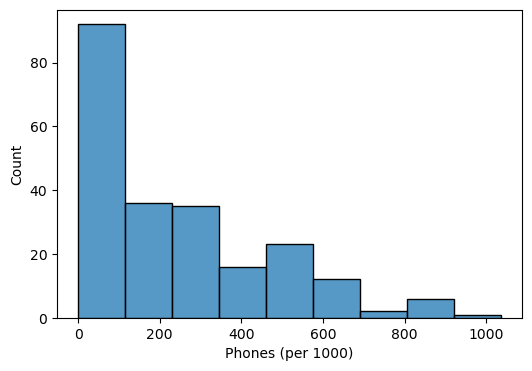

In [54]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Phones (per 1000)')
plt.show()

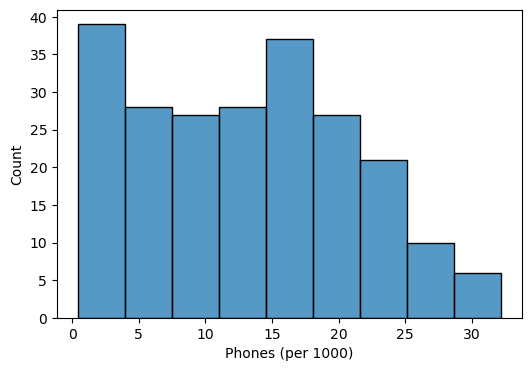

In [55]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['Phones (per 1000)'].apply(np.sqrt))
plt.show()

- Numerical Continuous feature with a Right Skewed distribution.
- Transformations: Square Root Transform, Scaling.

In [56]:
phones_pipe = Pipeline([
    ('imputer', Imputation(group_col= 'Region', target_col= 'Phones (per 1000)')),
    ('transformation', FunctionTransformer(np.sqrt)),
    ('scaler', StandardScaler())
])

###### 12) Arable (%):

In [57]:
df['Arable (%)']

0      12.13
1      21.09
2       3.22
3      10.00
4       2.22
       ...  
222    16.90
223     0.02
224     2.78
225     7.08
226     8.32
Name: Arable (%), Length: 227, dtype: float64

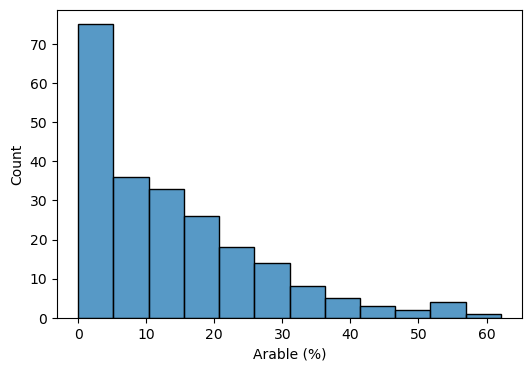

In [58]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Arable (%)')
plt.show()

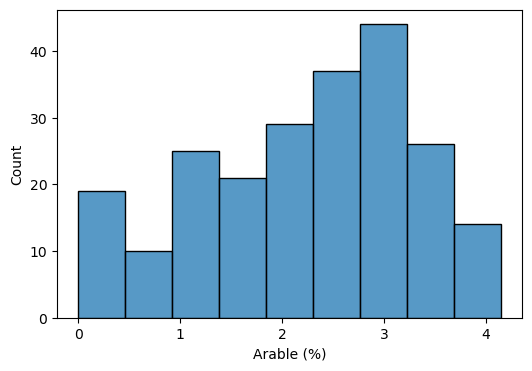

In [59]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['Arable (%)'].apply(np.log1p))
plt.show()

- Numerical Continuous feature with a Right Skewed distribution.
- Transformations: Log Transform, Scaling.

In [60]:
arable_pipe = Pipeline([
    ('imputer', Imputation(group_col= 'Region', target_col= 'Arable (%)')),
    ('transformation', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

###### 13) Crops (%):

In [61]:
df['Crops (%)']

0       0.22
1       4.42
2       0.25
3      15.00
4       0.00
       ...  
222    18.97
223     0.00
224     0.24
225     0.03
226     0.34
Name: Crops (%), Length: 227, dtype: float64

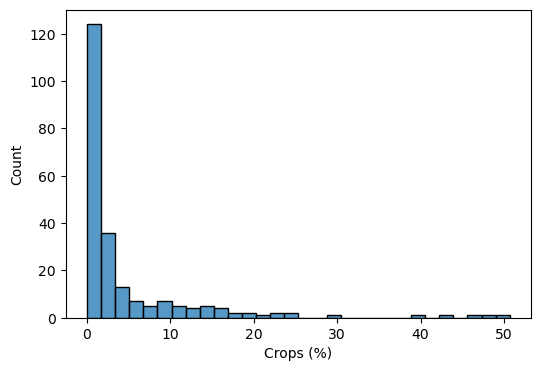

In [62]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Crops (%)')
plt.show()

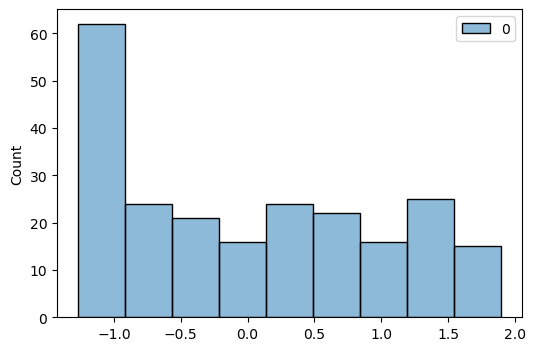

In [63]:
pt= PowerTransformer(method= 'yeo-johnson')

plt.figure(figsize= (6,4))
sns.histplot(data= pt.fit_transform(df[['Crops (%)']]))
plt.show()

- Numerical Continuous feature with a Right Skewed distribution.
- Transformations: Log Transform, Scaling.

In [64]:
crops_pipe = Pipeline([
    ('imputer', Imputation(group_col= 'Region', target_col= 'Crops (%)')),
    ('transformation', PowerTransformer(method= 'yeo-johnson')),
    ('scaler', StandardScaler())
])

###### 14) Other (%):

In [65]:
df['Other (%)']

0      87.65
1      74.49
2      96.53
3      75.00
4      97.78
       ...  
222    64.13
223    99.98
224    96.98
225    92.90
226    91.34
Name: Other (%), Length: 227, dtype: float64

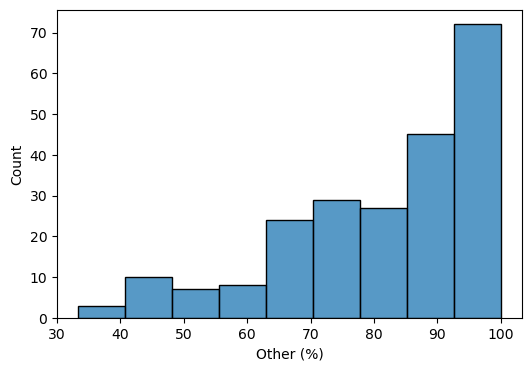

In [66]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Other (%)')
plt.show()

- Numerical, Continuous feature with left skewed distribution.
- Transformations:  Scaling (Log transformations don't work).

In [67]:
other_pipe = Pipeline([
    ('imputer', Imputation(group_col= 'Region', target_col= 'Other (%)')),
    ('scaler', StandardScaler())
])

###### 15) Climate:

In [68]:
df['Climate']

0      1.0
1      3.0
2      1.0
3      2.0
4      3.0
      ... 
222    3.0
223    1.0
224    1.0
225    2.0
226    2.0
Name: Climate, Length: 227, dtype: float64

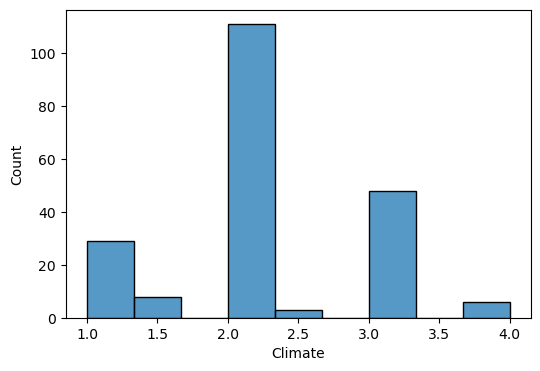

In [69]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Climate')
plt.show()

- Numerical, discrete feature.
- Transformation: Scaling.

In [70]:
climate_pipe = Pipeline([
    ('imputer', Imputation(group_col= 'Region', target_col= 'Climate')),
    ('scaler', StandardScaler())
])

###### 16) Birthrate:

In [71]:
df['Birthrate']

0      46.60
1      15.11
2      17.14
3      22.46
4       8.71
       ...  
222    31.67
223      NaN
224    42.89
225    41.00
226    28.01
Name: Birthrate, Length: 227, dtype: float64

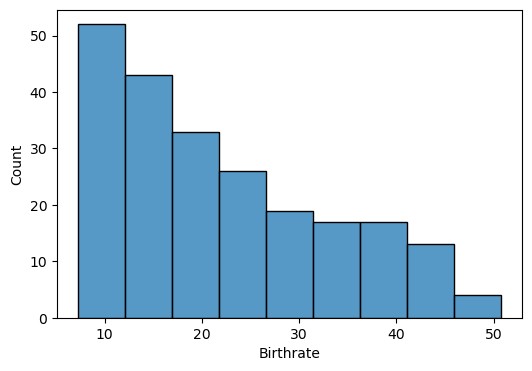

In [72]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Birthrate')
plt.show()

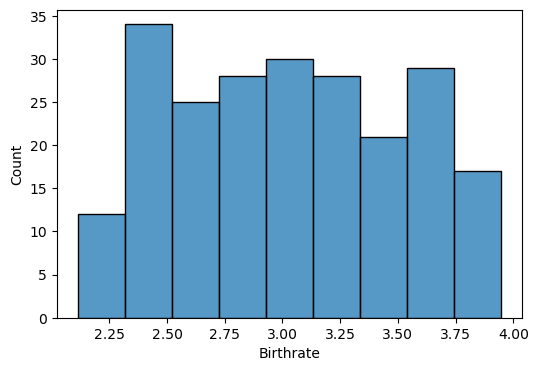

In [73]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['Birthrate'].apply(np.log1p))
plt.show()

- Numerical Continuous feature with a Right Skewed distribution.
- Transformations: Log Transform, Scaling.

In [74]:
birthrate_pipe = Pipeline([
    ('imputer', Imputation(group_col= 'Region', target_col= 'Birthrate')),
    ('transformation', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

###### 17) Deathrate:

In [75]:
df['Deathrate']

0      20.34
1       5.22
2       4.61
3       3.27
4       6.25
       ...  
222     3.92
223      NaN
224     8.30
225    19.93
226    21.84
Name: Deathrate, Length: 227, dtype: float64

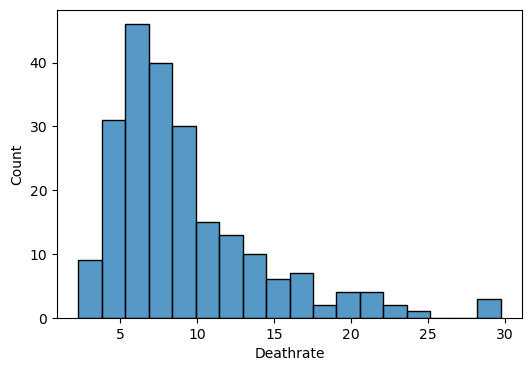

In [76]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Deathrate')
plt.show()

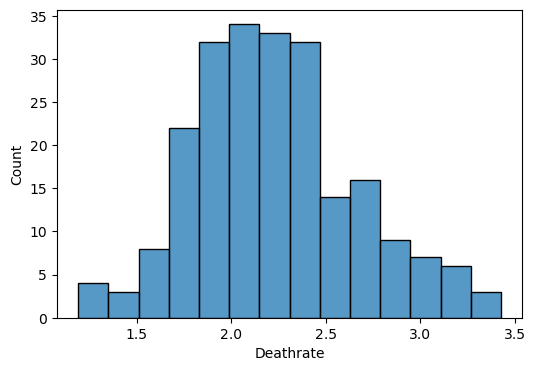

In [77]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['Deathrate'].apply(np.log1p))
plt.show()

- Numerical Continuous feature with a Right Skewed distribution.
- Transformations: Log Transform, Scaling.

In [78]:
deathrate_pipe = Pipeline([
    ('imputer', Imputation(group_col= 'Region', target_col= 'Deathrate')),
    ('transformation', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

###### 18) Agriculture:

In [79]:
df['Agriculture']

0      0.380
1      0.232
2      0.101
3        NaN
4        NaN
       ...  
222    0.090
223      NaN
224    0.135
225    0.220
226    0.179
Name: Agriculture, Length: 227, dtype: float64

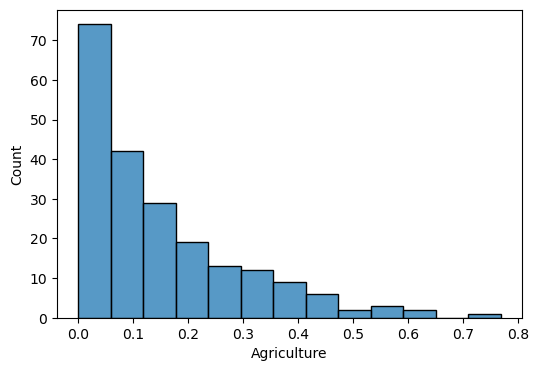

In [80]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Agriculture')
plt.show()

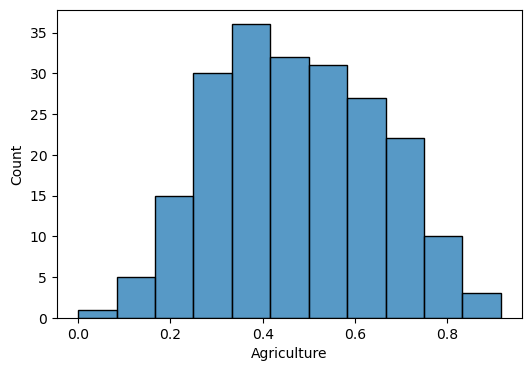

In [81]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['Agriculture'].apply(np.cbrt))
plt.show()

- Numerical Continuous feature with a Right Skewed distribution.
- Transformations: Cube Root Transform, Scaling.

In [82]:
agriculture_pipe = Pipeline([
    ('imputer', Imputation(group_col= 'Region', target_col= 'Agriculture')),
    ('transformation', FunctionTransformer(np.cbrt)),
    ('scaler', StandardScaler())
])

###### 19) Industry:

In [83]:
df['Industry']

0      0.240
1      0.188
2      0.600
3        NaN
4        NaN
       ...  
222    0.280
223      NaN
224    0.472
225    0.290
226    0.243
Name: Industry, Length: 227, dtype: float64

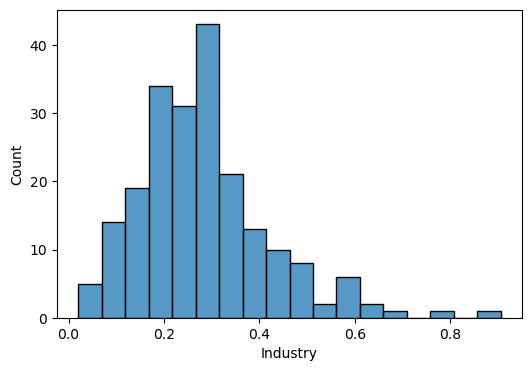

In [84]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Industry')
plt.show()

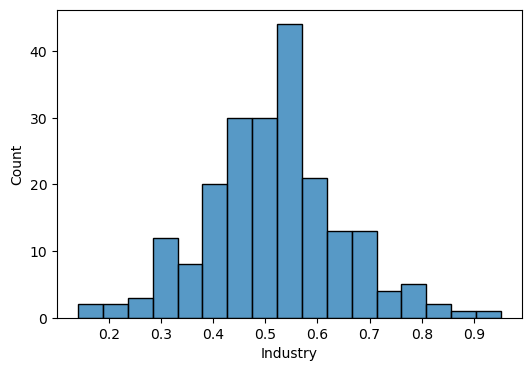

In [85]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['Industry'].apply(np.sqrt))
plt.show()

- Numerical Continuous feature with a slight Right Skewed distribution.
- Transformations: Square Root Transform, Scaling.

In [86]:
industry_pipe = Pipeline([
    ('imputer', Imputation(group_col= 'Region', target_col= 'Industry')),
    ('transformation', FunctionTransformer(np.sqrt)),
    ('scaler', StandardScaler())
])

###### 20) Service:

In [87]:
df['Service']

0      0.380
1      0.579
2      0.298
3        NaN
4        NaN
       ...  
222    0.630
223    0.400
224    0.393
225    0.489
226    0.579
Name: Service, Length: 227, dtype: float64

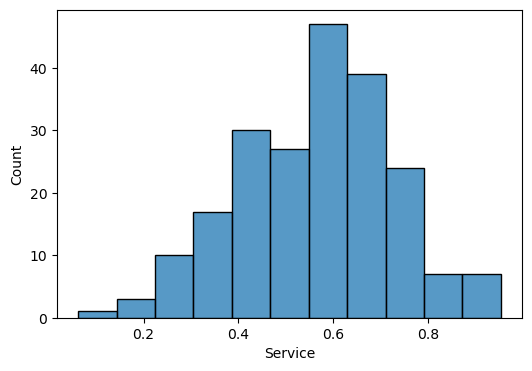

In [88]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Service')
plt.show()

- Numerical Continuous feature with close to Normal Distribution.
- Transformations: Scaling.

In [89]:
service_pipe = Pipeline([
    ('imputer', Imputation(group_col= 'Region', target_col= 'Service')),
    ('scaler', StandardScaler())
])

#### 4) Final Column Transformer:

In [90]:
df.columns

Index(['Region', 'Population', 'Area (sq. mi.)', 'Pop. Density (per sq. mi.)',
       'Coastline (coast/area ratio)', 'Net migration',
       'Infant mortality (per 1000 births)', 'GDP ($ per capita)',
       'Literacy (%)', 'Phones (per 1000)', 'Arable (%)', 'Crops (%)',
       'Other (%)', 'Climate', 'Birthrate', 'Deathrate', 'Agriculture',
       'Industry', 'Service'],
      dtype='object')

In [91]:
preprocessor = ColumnTransformer([
    ('Region', region_pipe, ['Region']),
    ('Population', population_pipe, ['Population']),
    ('Area (sq. mi.)', area_pipe, ['Area (sq. mi.)']),
    ('Pop. Density (per sq. mi.)', popdensity_pipe, ['Pop. Density (per sq. mi.)']),
    ('Coastline (coast/area ratio)', coastline_pipe, ['Coastline (coast/area ratio)']),
    ('Net migration', netmig_pipe, ['Region', 'Net migration']),
    ('Infant mortality (per 1000 births)', infantMRate_pipe, ['Region', 'Infant mortality (per 1000 births)']),
    ('GDP ($ per capita)', GDP_pipe, ['Region', 'GDP ($ per capita)']),
    ('Literacy (%)', literacy_pipe, ['Region', 'Literacy (%)']),
    ('Phones (per 1000)', phones_pipe, ['Region', 'Phones (per 1000)']),
    ('Arable (%)', arable_pipe, ['Region', 'Arable (%)']),
    ('Crops (%)', crops_pipe, ['Region', 'Crops (%)']),
    ('Other (%)', other_pipe, ['Region', 'Other (%)']),
    ('Climate', climate_pipe, ['Region', 'Climate']),
    ('Birthrate', birthrate_pipe, ['Region', 'Birthrate']),
    ('Deathrate', deathrate_pipe, ['Region', 'Deathrate']),
    ('Agriculture', agriculture_pipe, ['Region', 'Agriculture']),
    ('Industry', industry_pipe, ['Region', 'Industry']),
    ('Service', service_pipe, ['Region', 'Service'])
],
                                 remainder= 'passthrough')